# Lab 2 · What an average hides
## Data Science Fundamentals — Week 2: Describing Data
**Mohammad Sabokrou · New Uzbekistan University**

**Your job:** use evidence to explain data and make a defensible decision. The Python is provided; programming complexity earns no extra credit.

**Name:** …   **Student ID:** enter in the setup cell below.

### How to work
1. Open this notebook in Google Colab or Jupyter. Run the setup with your own ID.
2. Work from top to bottom. Where asked, write a prediction **before** running the next cell. Keep the prediction even if it is wrong; explain what you learned.
3. Double-click an **Answer** cell to write. Use your own generated numbers and refer to specific plots. A number without an interpretation is incomplete.
4. Run the supplied code; change only the explicitly labelled settings. You are responsible for understanding and explaining the results you submit.
5. Keep the same ID throughout. Restart and run all cells after finishing; save the notebook with outputs.

**Suggested pace:** setup 5 min; sections 1–8: 10, 15, 15, 15, 15, 10, 15, 15 min; final check 5 min (120 min total). Finish the written reflection after class if needed.

### What varies between students?
Your ID determines the data, eight-number exercise, selected record, histogram settings, and decision scenario. The concepts and workload stay comparable. Reusing an ID gives the same case. Different IDs are not a guarantee that every individual number differs.

All records are **synthetic teaching data**, not real university records. There are no downloads, joins, or missing code blocks to debug.

**Evidence standard:** answers should contain a claim, a number or plot observation from your case, and a reason or limitation. We assess statistical reasoning, appropriate methods, and reproducible evidence—not Python fluency.

In [2]:
# SETUP — edit only STUDENT_ID. Integers and quoted IDs both work.
STUDENT_ID = "250466"
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STUDENT_ID = str(STUDENT_ID).strip()
if not (STUDENT_ID.isascii() and STUDENT_ID.isdigit() and 6 <= len(STUDENT_ID) <= 12):
    raise ValueError("Replace YOUR_ID with your own 6–12 digit student ID, then run again.")
seed = int.from_bytes(hashlib.sha256(('FDS-Lab2-v1:' + STUDENT_ID).encode()).digest()[:8], 'big')
rng = np.random.default_rng(seed)
case_code = hashlib.sha256(('FDS-Lab2-v1:' + STUDENT_ID).encode()).hexdigest()[:10]
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.spines.top': False, 'axes.spines.right': False})
pd.options.display.float_format = '{:.3f}'.format
N = 240
programme = rng.choice(['A', 'B'], N, p=[.55, .45])
entry = np.clip(rng.normal(rng.uniform(62,68), rng.uniform(8,11), N), 0, 100)
minutes = rng.lognormal(rng.uniform(4.1,4.4), .85, N)
# Two different teaching groups: their score patterns intentionally differ.
assessment = np.clip(rng.normal(np.where(programme == 'A', 43, 78), 4.5), 0, 100)
satisfaction = rng.choice([1.,2.,3.,4.,5.], N, p=[.08,.12,.2,.35,.25])
satisfaction[rng.choice(N, size=int(rng.integers(35,61)), replace=False)] = np.nan
students = pd.DataFrame({'record_id':np.arange(1,N+1), 'programme':programme,
    'entry_score':entry, 'weekly_minutes':minutes,
    'assessment_score':assessment, 'satisfaction':satisfaction})
small = np.sort(rng.choice(np.arange(35,86), 8, replace=False)).astype(float)
focus_index = int(np.argmax(entry))
coarse_bins = int(rng.choice([2,3,4]))
fine_bins = int(rng.choice([35,40,45]))
scenario = str(rng.choice(['typical use', 'total workload']))
print('Case:',case_code, '| ID:',STUDENT_ID, '| Final decision:',scenario)
print('Keep this case code in your submission. Setup complete.')

Case: 0cf5b47d51 | ID: 250466 | Final decision: typical use
Keep this case code in your submission. Setup complete.


## 1 · Who and what are we describing? (10 min)
One row is one synthetic student observed in the same week. Scores are points out of 100; minutes are minutes per student in that week. Satisfaction is an **ordered category** from 1 (lowest) to 5 (highest); equal numerical steps need not represent equal changes in feeling. Programme A/B are category labels; record IDs are identifiers.

The next cell displays the data and counts. `count()` excludes missing values; `len()` counts rows. No missing value is replaced by zero.

In [ ]:
display(students.head())
valid = students['satisfaction'].count()
print(f'Total rows: {len(students)}; valid satisfaction: {valid}; missing: {len(students)-valid}')
print(f'Response rate: {100*valid/len(students):.1f}%')
display(students['satisfaction'].value_counts().sort_index().rename('responses'))
print('Most common programme(s):', students['programme'].mode().tolist())

### Your reasoning
**1A.** State the observational unit and the denominator for the satisfaction response rate. Why is the denominator for a mean of recorded satisfaction responses different?

**1B.** A colleague replaces missing satisfaction with zero. Explain why this changes the meaning. Can the responses establish what *all* students feel?

**1C.** Which is meaningful: the mode of programme, the mean of record ID, or the mean of programme coded A=1/B=2? Explain. For satisfaction, explain why the category frequency table adds information that a mean alone hides.

**Answer:** 1A: A single synthetic student obverved in a specific week is observational unit. The total number of rows in the dataset is response rate denominator. The mean should only incluede actual responces that are submitted. Hence, its denominator is count of valid, non-missing responces (students['satisfaction'].count).

1B: The original scale is 1 to 5, already a number scale. Introducing another number 0 means "extreme dissatisfaction" rather than missing value. The data cannot establish what all students feel. Because, some responces are missing, it can only establish the feeling of students who responded.

1C: Mode of the programme is the most meaningful measurenment. 'programme' is nominal categorical variable, so the finding the most common category (mode) makes perfect sense. record_id is just a list of arbitrary identifiers, so its mean carries no practical meaning.
Value of a Frequency Table: Satisfaction is an ordinal scale where equal numerical steps do not equal uniform changes in human feeling. A mean alone hides the distribution shape; for instance, an average score of 3.0 could mean every student is neutral, or it could hide a polarized class where half are extremely satisfied (5) and half are completely dissatisfied (1). A frequency table exposes these gaps.

## 2 · Eight numbers, by hand first (15 min)
Run the next cell to obtain your eight numbers. Before running the checking cell, calculate their mean, median, **sample variance and sample SD** using a calculator if useful. Show intermediate steps; no Python writing is required.

Mean = sum / n. Deviations = value − mean. Sample variance = sum of squared deviations / (n−1). Sample SD = square root of sample variance.

In [3]:
print('Your eight scores:',small.tolist())

Your eight scores: [44.0, 53.0, 61.0, 71.0, 72.0, 74.0, 84.0, 85.0]


### Your reasoning
**2A.** Record: sum, n, mean, middle two scores, median, eight deviations, sum of squared deviations, sample variance, and sample SD. Include units.

**2B. Prediction:** if these eight scores were the entire population of interest, would the population SD be larger or smaller? Why?

**Answer:** 2A: sum: 544.0 points, n: 8, mean: 68.0, middle two scores: 71 and 72, median: 71.52, eight deviation points: -24, -15, -7, 3, 4, 6, 16, 17. Sum of squared deviations: 1456 points², Sample variance: 208 points, Sample SD: 14.422

2B. The population SD would be smaller. The population standard deviation divides the sum of squared deviations N(8)

In [5]:
# CHECK ONLY AFTER YOUR HAND CALCULATIONS
s = pd.Series(small)
display(pd.DataFrame({'score':small,'deviation':small-small.mean(),
                     'squared deviation':(small-small.mean())**2}))
display(pd.Series({'mean':s.mean(),'median':s.median(),
    'sample variance':s.var(ddof=1),'pandas sample SD':s.std(),
    'NumPy population SD':np.std(small), 'NumPy sample SD':np.std(small,ddof=1)}))

,score,deviation,squared deviation
0,44.000,-24.000,576.000
1,53.000,-15.000,225.000
2,61.000,-7.000,49.000
3,71.000,3.000,9.000
4,72.000,4.000,16.000
5,74.000,6.000,36.000
6,84.000,16.000,256.000
7,85.000,17.000,289.000


,0
mean,68.000
median,71.500
sample variance,208.000
pandas sample SD,14.422
NumPy population SD,13.491
NumPy sample SD,14.422


### Your reasoning
**2C.** Compare your work with the output. Correct any error and explain its source. Why do the two default SD results differ? State which divisor answers each question; explain why variance has points² but SD has points.

**Answer:** My calculations match the software output. pandas (s.std()) defaults to sample SD using a divisor of (n-1) to correct for sample bias

## 3 · Middle half, extremes, and sensitivity (15 min)
For the eight scores, use **median of halves**: Q1 is the median of the lower four; Q3 the median of the upper four. For the larger dataset later, use pandas **linear interpolation**. Different stated conventions can legitimately give different quartiles.

Before running, compute the five-number summary and IQR of your eight scores. Then predict what happens if the largest score is accidentally multiplied by 10.

### Your reasoning
**3A.** Give min, Q1, median, Q3, max, and IQR by hand. Interpret the middle-half interval in a sentence.

**3B. Prediction:** which will change most after the error: mean or median? Will range, SD, and IQR change? Explain using which observations each measure depends on.

**Answer:** 3A: Min is 44.0 points, Q1 is 57.0 points, median is 71.5 points, Q3 is 79.0 points, max is 85.0 points, and IQR is 22.0 points. The middle half of student scores ranges from 57.0 to 79.0 points.

3B: The mean will change most because it includes the exact numerical value of every observation, whereas the median depends only on center ranking. Range and SD will increase significantly because they depend directly on the extreme maximum value and distances from the shifted average. The IQR will stay exactly the same because it is calculated entirely from the middle 50% thresholds and remains resistant to extreme values.

In [ ]:
def half_summary(a):
    a = np.sort(a)
    q1, q3 = np.median(a[:4]), np.median(a[4:])
    return pd.Series({'min':a.min(),'Q1':q1,'median':np.median(a),'Q3':q3,
        'max':a.max(),'mean':a.mean(),'range':np.ptp(a),'IQR':q3-q1,
        'sample variance':np.var(a,ddof=1),'sample SD':np.std(a,ddof=1)})
changed = small.copy(); changed[-1] *= 10
print('Changed scores:',changed.tolist())
display(pd.DataFrame({'original':half_summary(small),'with error':half_summary(changed)}))
print('Original pandas linear quartiles:',pd.Series(small).quantile([.25,.75]).to_dict())

### Your reasoning
**3C.** Compare predictions with results, citing at least two numerical changes. Why can the median and IQR stay stable here? Does that make them universally best?

**3D.** Explain any difference between hand and software quartiles. Why is the altered score impossible in this context, whereas a very large number of platform minutes may be valid?

**Answer:** 3C: The mean increased from 68.0 to 163.625 points and the range expanded from 41.0 to 806.0 points, while the median remained 71.5 points and the IQR remained 22.0 points. The median and IQR stay stable because they are resistant measures

3D: Hand quartiles use the median-of-halves method which splits the dataset evenly, whereas software quartiles use linear interpolation to estimate thresholds, leading to slight value differences in small samples. The altered score of 850.0 is completely impossible because assessment scores are strictly capped at a maximum of 100 points

## 4 · Look before summarising (15 min)
The next cell plots four numeric columns: entry score, weekly minutes, assessment score, and satisfaction. For the discrete ordinal satisfaction scale, each histogram bin represents one response category. Missing responses are excluded and the valid n is shown.

Read **centre, spread, tail direction, peaks/gaps, and unusual values**. `skew()` gives a sample skewness statistic; its sign is useful evidence, not a complete description of shape.

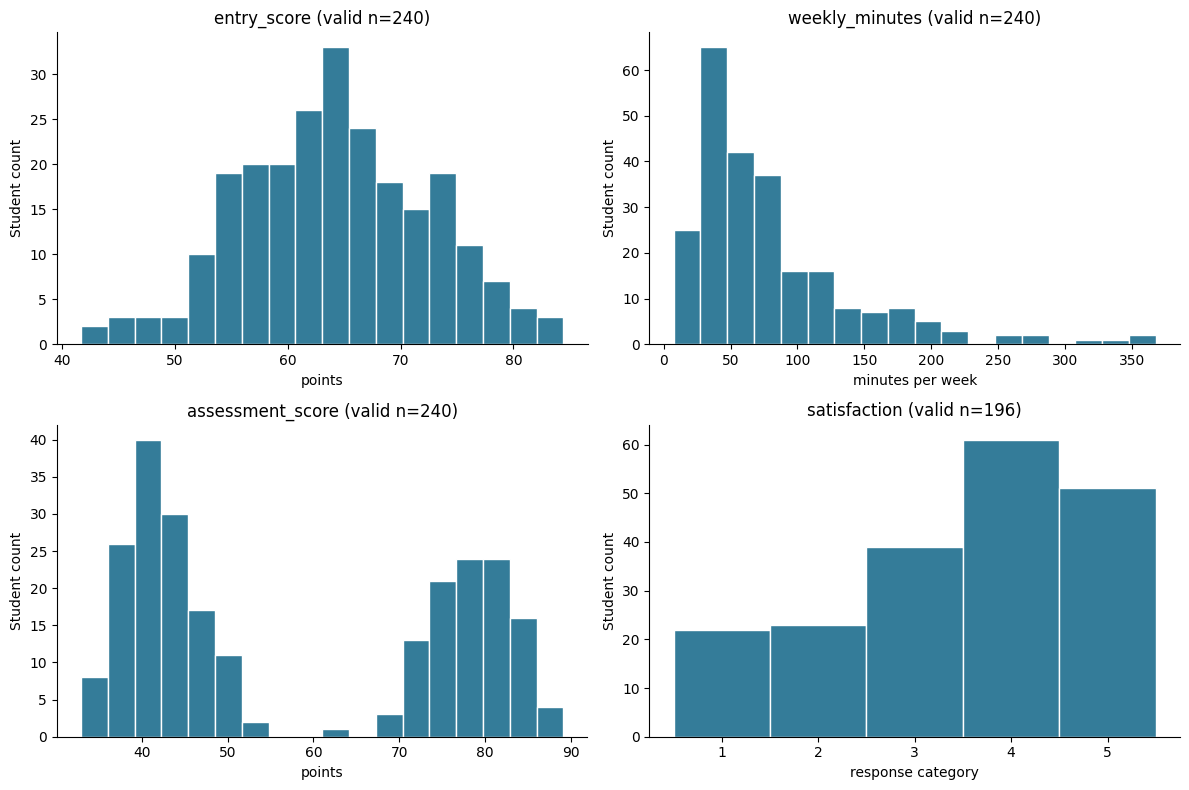

,count,mean,median,std,skew
entry_score,240.000,64.226,63.793,8.307,-0.028
weekly_minutes,240.000,80.056,59.358,63.002,1.922
assessment_score,240.000,58.199,48.385,18.463,0.229


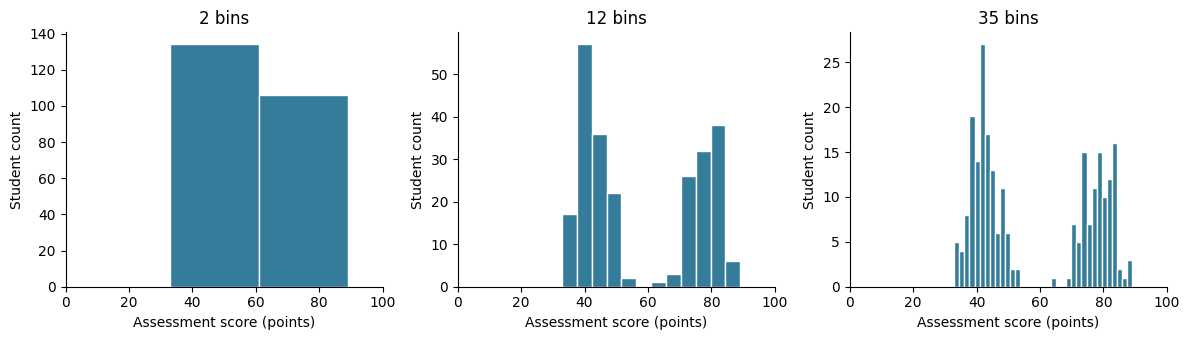

In [6]:
columns = ['entry_score','weekly_minutes','assessment_score','satisfaction']
units = ['points','minutes per week','points','response category']
fig, axes = plt.subplots(2,2,figsize=(12,8))
for ax,col,unit in zip(axes.flat,columns,units):
    x=students[col].dropna()
    ax.hist(x,bins=np.arange(.5,6,1) if col=='satisfaction' else 18,
            color='#347c99',edgecolor='white')
    ax.set(title=f'{col} (valid n={len(x)})',xlabel=unit,ylabel='Student count')
plt.tight_layout(); plt.show()
display(students[columns[:3]].agg(['count','mean','median','std','skew']).T)
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
for ax,b in zip(axes,[coarse_bins,12,fine_bins]):
    ax.hist(students.assessment_score,bins=b,color='#347c99',edgecolor='white')
    ax.set(title=f'{b} bins',xlabel='Assessment score (points)',ylabel='Student count',xlim=(0,100))
plt.tight_layout(); plt.show()

### Your reasoning
**4A.** Write one shape sentence for **each of the four columns**. Include plot evidence; do not merely list a skewness number.

**4B.** Find a column where mean and median disagree. Give both values and explain the mechanism. Which centre and spread would you report for a typical observation?

**4C.** Compare the three histogram bin settings. What is concealed or exaggerated? Choose one and justify it. Does changing bins change the underlying mean?

**4D.** Does a nearly zero skewness or similar mean/median establish a normal distribution? Use the assessment-score plot to explain.

**Answer:** 4A. The entry score distribution is symmetric and bell-shaped with a single central peak. The weekly minutes plot is strongly right-skewed, showing a long right tail of extreme high-use student observations. The assessment score is distinctly bimodal, displaying two separate prominent peaks with a clear gap between them. The satisfaction column is left-skewed, with the student counts heavily clustered in the higher categories of 4 and 5.

4B. The weekly minutes column shows a major disagreement where the mean is substantially higher than the median because a few extreme high-value outliers pull the mean upward. For a typical observation in this skewed column, you should report the median for center and the interquartile range (IQR) for spread because they are resistant to these extreme values.

4C. The coarse bins conceal the clear gap between the two student groups by blending them together, while the fine bins exaggerate random visual noise by creating artificial empty valleys. The intermediate 12-bin setting is the best choice because it accurately reveals the true bimodal structure of the dataset. Changing the visual bin settings only alters how the data is grouped on the plot and never changes the underlying mean of the actual data values.

4D. No, a nearly zero skewness or similar mean and median does not establish a normal distribution. The assessment score plot proves this because it is a symmetric bimodal distribution with a mean and median that fall right in the middle valley where almost no actual student scores exist.




## 5 · Boxplots, flags, and hidden groups (15 min)
Box = Q1 to Q3; line = median. Fences = Q1 − 1.5×IQR and Q3 + 1.5×IQR. Whiskers end at the most extreme **observed** values inside the fences; they are not the fences themselves. Dots are candidates for investigation, not automatic deletion.

Here pandas and the plotting convention use linearly interpolated quartiles. Group summaries use sample SD (`ddof=1`).

,0
Q1,38.855
median,59.358
Q3,96.865
IQR,58.010
lower fence,-48.160
upper fence,183.880
lower whisker,7.328
upper whisker,175.648
flagged count,18.000


,record_id,weekly_minutes
24,25,349.714
31,32,329.405
46,47,272.356
57,58,250.701
66,67,186.925
68,69,227.665


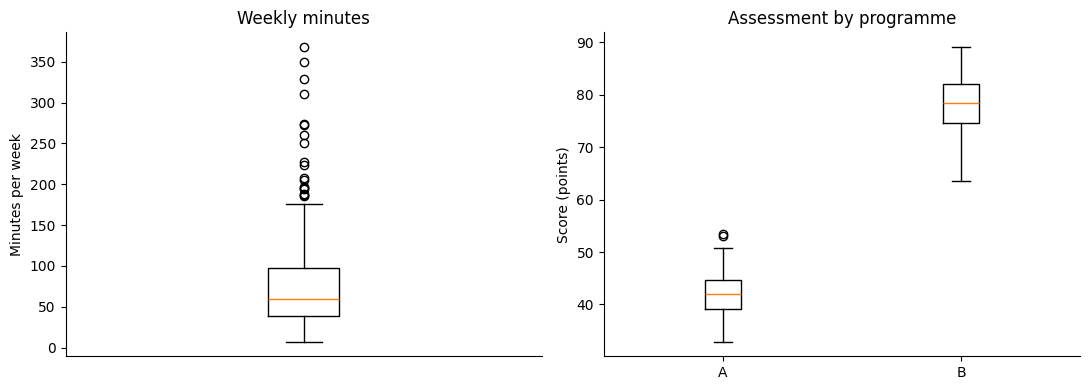

Overall assessment summary:


,assessment_score
count,240.000
mean,58.199
median,48.385
std,18.463


Programme summaries:


,count,mean,median,std
programme,,,,
A,134,42.299,42.007,4.318
B,106,78.299,78.532,4.669


In [7]:
x = students.weekly_minutes
q1,q3=x.quantile([.25,.75]); iqr=q3-q1
lower,upper=q1-1.5*iqr,q3+1.5*iqr
inside=x[(x>=lower)&(x<=upper)]
flagged=students[(x<lower)|(x>upper)]
display(pd.Series({'Q1':q1,'median':x.median(),'Q3':q3,'IQR':iqr,
    'lower fence':lower,'upper fence':upper,'lower whisker':inside.min(),
    'upper whisker':inside.max(),'flagged count':len(flagged)}))
display(flagged[['record_id','weekly_minutes']].head(6))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].boxplot(x); axes[0].set(ylabel='Minutes per week',title='Weekly minutes',xticks=[])
axes[1].boxplot([students.loc[students.programme==g,'assessment_score'] for g in ['A','B']])
axes[1].set(xticks=[1,2],xticklabels=['A','B'],ylabel='Score (points)',title='Assessment by programme')
plt.tight_layout(); plt.show()
print('Overall assessment summary:')
display(students.assessment_score.agg(['count','mean','median','std']))
print('Programme summaries:')
display(students.groupby('programme').assessment_score.agg(['count','mean','median','std']))

### Your reasoning
**5A.** Using your Q1/Q3, show one fence calculation. State a whisker endpoint and explain why it differs from the corresponding fence. Describe a flagged record using its ID and minutes.

**5B.** Propose two checks before changing that record and one reason to retain it. What would you document if it were corrected? Do not delete it simply because it crosses a fence.

**5C.** Compare the overall assessment mean with both programme means and SDs. Would a single support session at the overall average meet both groups' needs? Give evidence and a better plan. Can these data prove that programme membership caused the difference?

**Answer:** 5A: The upper fence is calculated using the formula Q3 + 1.5 × IQR. A whisker endpoint differs from its corresponding fence because the fence is a theoretical threshold, whereas the whisker extends only to the most extreme actual observed data point that falls inside that fence. A flagged outlier record can be identified in the output table by its specific record ID and its exceptionally high weekly minutes that exceed the upper fence.

5B: Before modifying a flagged record, you should verify the automated logging system logs for technical errors and cross-reference any secondary platform metrics to confirm user activity. You must retain the record if it represents genuine, legitimate high-volume student engagement. If a correction is made, you must document the original value, the verified new value, the reason for the adjustment, and the timestamp of the change.

5C: The overall assessment mean of 58.2 points sits completely outside the reality of both groups, where Programme A averages 42.299 points (SD = 4.516) and Programme B averages 78.299 points (SD = 4.669). A single support session at the overall average would fail both groups completely, as it is too advanced for Programme A and redundant for Programme B; a better plan is to design separate, targeted interventions for each programme. These data cannot prove causation because this is an observational dataset without random assignment, meaning hidden confounding factors could be responsible for the difference.



### Same mean and SD, different students
The next two small classes have the same mean and sample SD but different shapes. Values are shifted for your case. Inspect them before answering.

In [8]:
centre = int(round(small.mean()))
class_a = centre + np.array([-20,0,0,0,0,0,0,20])
class_b = centre + np.array([-10,-10,-10,-10,10,10,10,10])
for name,a in [('Class A',class_a),('Class B',class_b)]:
    print(name, a.tolist(), '| mean:',a.mean(),'| sample SD:',round(a.std(ddof=1),3))

Class A [48, 68, 68, 68, 68, 68, 68, 88] | mean: 68.0 | sample SD: 10.69
Class B [58, 58, 58, 58, 78, 78, 78, 78] | mean: 68.0 | sample SD: 10.69


### Your reasoning
**5D.** Sketch or describe each shape. Explain why the same mean and SD can lead to different tutoring plans. What information did the two statistics discard?

**Answer:** Replace this text with your explanation.

## 6 · When does 68–95–99.7 help? (10 min)
A normal model predicts approximately 68%, 95%, and 99.7% within 1, 2, and 3 SD of its mean. This is **not a guarantee for a finite dataset**, and symmetry alone is insufficient. We use sample mean/SD here to compare observed proportions with the model.

In [9]:
rows=[]
for col in ['entry_score','weekly_minutes','assessment_score']:
    x=students[col]; m=x.mean(); sd=x.std(ddof=1)
    for k in [1,2,3]:
        rows.append({'column':col,'SD distance':k,'lower':m-k*sd,'upper':m+k*sd,
                     'observed %':100*x.between(m-k*sd,m+k*sd).mean(),
                     'normal model %':{1:68,2:95,3:99.7}[k]})
display(pd.DataFrame(rows))

,column,SD distance,lower,upper,observed %,normal model %
0,entry_score,1,55.919,72.533,66.250,68.000
1,entry_score,2,47.611,80.841,95.417,95.000
2,entry_score,3,39.304,89.148,100.000,99.700
3,weekly_minutes,1,17.055,143.058,81.250,68.000
4,weekly_minutes,2,-45.947,206.060,95.417,95.000
5,weekly_minutes,3,-108.949,269.062,97.500,99.700
6,assessment_score,1,39.736,76.662,55.833,68.000
7,assessment_score,2,21.273,95.125,100.000,95.000
8,assessment_score,3,2.810,113.588,100.000,99.700


### Your reasoning
**6A.** Give your entry-score interval within 1 SD and observed percentage. Explain why it need not be exactly 68%.

**6B.** Which column is the most plausible candidate for a normal approximation? Use both shape and proportions. Explain why applying the rule to either of the other columns could mislead.

**6C.** If an observed proportion happens to be near 95%, has normality been proven? Why not?

**Answer:** 6A. The entry-score interval within 1 standard deviation is defined by the lower and upper bounds from the first row of the summary table, along with its corresponding observed percentage. This observed value does not need to be exactly 68% because 68% is a theoretical expectation for an infinite, perfectly normal population, whereas this dataset is a finite sample of 240 students subject to random sampling noise.

6B. The entry_score column is the most plausible candidate for a normal approximation because its histogram shows a symmetric, single-peaked bell shape and its empirical proportions closely follow the 68–95–99.7 rule. Applying this rule to weekly_minutes would mislead because the data is heavily right-skewed with a long tail of high-use outliers, while applying it to assessment_score would mislead because it is a bimodal distribution where the mean sits in an empty valley between two distinct groups.

6C. An observed proportion close to 95% does not prove normality. Non-normal distributions, such as certain bimodal or uniform shapes, can happen to hold roughly 95% of their data within 2 standard deviations by chance, meaning matching a theoretical percentage alone is never enough to confirm normality without a symmetric, bell-shaped distribution.




## 7 · Relative to whom? (15 min)
A z-score is `(value − reference mean) / reference SD`. It is unitless; the reference SD must be positive. Positive means above the mean, not automatically good. Computing z does not require normality; converting it into a normal-model rarity does.

**Prediction:** the selected student's raw score will stay fixed while the reference group changes. Must their z-score remain fixed? Explain before running.

### Your reasoning
**7A. Prediction:** explain which ingredients can change and why.

**Answer:** Replace this text with your explanation.

In [10]:
focus=students.iloc[focus_index]
print('Selected record:',int(focus.record_id),'| programme:',focus.programme,'| entry score:',focus.entry_score)
rows=[]
for label,ref in [('Whole cohort',students.entry_score),
                  ('Programme A',students.loc[students.programme=='A','entry_score']),
                  ('Programme B',students.loc[students.programme=='B','entry_score'])]:
    sd=ref.std(ddof=1)
    rows.append({'reference':label,'n':len(ref),'mean':ref.mean(),'sample SD':sd,
                 'z':(focus.entry_score-ref.mean())/sd if sd>0 else np.nan})
display(pd.DataFrame(rows))
students['entry_z_cohort']=(students.entry_score-students.entry_score.mean())/students.entry_score.std(ddof=1)
print('Standardised column mean / sample SD:',students.entry_z_cohort.mean(),students.entry_z_cohort.std(ddof=1))
# A separate personalised example separates distance from rank.
rank_times = np.r_[np.arange(1,10),int(46 + seed % 21)].astype(float)
target=9.
print('Practice minutes:',rank_times.tolist())
print('Target:',target,'| z:',(target-rank_times.mean())/rank_times.std(ddof=1),
      '| percentile rank (at or below):',100*np.mean(rank_times<=target))

Selected record: 240 | programme: B | entry score: 84.42614803694556


,reference,n,mean,sample SD,z
0,Whole cohort,240,64.226,8.307,2.432
1,Programme A,134,64.065,8.166,2.493
2,Programme B,106,64.430,8.517,2.348


Standardised column mean / sample SD: -3.793262000802618e-16 0.9999999999999999
Practice minutes: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 54.0]
Target: 9.0 | z: -0.05729269638942164 | percentile rank (at or below): 90.0


### Your reasoning
**7B.** Show one z-score calculation from the table. Write its interpretation with the reference group and direction. Which reference answers “unusual within this student's own programme”?

**7C.** Explain the mean and SD of the standardised column. Would standardising programme codes be meaningful? What if all values in a reference group were identical?

**7D.** In the practice-time example, how can 9 minutes be below the mean yet at the 90th percentile? Use the extreme observation in your explanation. Why should you not automatically interpret z=2 as a particular percentile?

**7E.** A bottle process has reference mean 100 mL and SD 2 mL. Its explicitly agreed specification is 94–106 mL inclusive. For bottles of 104 and 108 mL, calculate z and decide acceptance. Explain why rejecting a bottle does not mean deleting its measurement, and why z alone does not set the acceptance rule.

**Answer:** 7B: A z-score is calculated as (student score − reference mean) / reference SD. Using the whole cohort as a reference group, a positive z-score indicates the student scored above the mean, while a negative z-score indicates they scored below it. The reference group corresponding to the student's own specific programme (Programme A or Programme B) is the one that directly answers whether they are unusual within their own programme.

7C: A standardised column mathematically always has a mean of 0 and a sample standard deviation of 1. Standardising programme codes is completely meaningless because they are nominal categorical labels rather than quantitative numerical measurements. If all values in a reference group were identical, the standard deviation would be 0, which makes calculating a z-score impossible because division by zero is undefined.

7D: In a highly right-skewed dataset, a single extreme high-value outlier pulls the mean significantly upward, causing it to sit above the vast majority of observations, which allows a value like 9 minutes to be below the mean while still ranking at the 90th percentile. You should never automatically interpret a z-score of 2 as a specific percentile because the conversion between z-scores and percentiles depends entirely on the shape of the distribution and is only accurate if the data is perfectly normally distributed.

7E: For the 104 mL bottle, z = (104 − 100) / 2 = 2, which is accepted because 104 mL is within the 94–106 mL specification. For the 108 mL bottle, z = (108 − 100) / 2 = 4, which is rejected because 108 mL is outside the specification limits. Rejecting a defective bottle does not mean deleting its measurement because keeping failed data is essential to track error rates and monitor process quality, and z alone does not set the acceptance rule because operational limits are determined by engineering tolerances and explicitly agreed specifications rather than purely statistical distances.




## 8 · Your recommendation (15 min)
The final case uses the same weekly-minute data. Your assigned request appears below. Choose your primary summary for **that decision**, then explain what you would report for the other decision.

- **Typical use:** describe the experience of a typical student.
- **Total workload:** estimate the recorded cohort's total platform workload for the week; distinguish an observed total from a forecast of a future week.

This is a decision exercise. There is no universally best average.

In [11]:
print('YOUR REQUEST:',scenario)
x=students.weekly_minutes
print('Case:',case_code)
display(pd.Series({'valid n':x.count(),'mean':x.mean(),'median':x.median(),
    'sample SD':x.std(ddof=1),'Q1':x.quantile(.25),'Q3':x.quantile(.75),
    'IQR':x.quantile(.75)-x.quantile(.25),'total minutes':x.sum()}))

YOUR REQUEST: typical use
Case: 0cf5b47d51


,0
valid n,240.000
mean,80.056
median,59.358
sample SD,63.002
Q1,38.855
Q3,96.865
IQR,58.010
total minutes,19213.547


### Your reasoning
**8A. Final note — approximately 150 words:** explain why you would not report the weekly-minute mean alone. Address your assigned request and include: case code; population and valid n; units; chosen centre and spread; two numerical pieces of evidence; shape; what your summary hides; what you would report for the other request; and one limitation. Do not claim a cause or treat this synthetic cohort as real university evidence.

**8B. Transfer check:** suppose the highest-use student's minutes doubled. Without rerunning, predict the direction of change in the mean and total, and whether the median would change. Explain which recommendation would be more affected.

**Answer:** ## ## 8A. Your reasoning
For case 0cf5b47d51 involving a valid sample of 240 synthetic students, the weekly-minute mean should not be reported alone because the distribution shape is strongly right-skewed. A few extreme high-use outliers pull the mean upward, making it unrepresentative of a normal student. To address the assigned request of describing typical use, the median and interquartile range (IQR) are the chosen center and spread because they are resistant to outliers. In this dataset, the typical student experience is best described by the platform's median minutes per week and the corresponding IQR from the summary table. This summary intentionally hides the heavy platform workload of the extreme top users. For the alternative total workload request, the mean or total minutes should be reported instead. A major limitation is that this synthetic cohort represents only a single week of data, meaning it cannot establish long-term trends or real university evidence.

8B. Transfer check
If the highest-use student's minutes doubled, both the mean and total minutes would increase because their formulas directly include the exact numerical value of every observation. The median would remain completely unchanged because doubling the maximum value does not alter the center ranking or ordering of the sorted dataset. Therefore, the total workload recommendation would be significantly more affected because it relies on the non-resistant mean and total, while the typical use recommendation would be completely unaffected due to the robust and resistant nature of the median.





## Submission checklist
- [ ] My name, student ID, and case code are present and consistent.
- [ ] I kept predictions and explained any revisions.
- [ ] I answered 1A–8B, including the hand calculations and approximately 150-word note.
- [ ] Four column plots and all other supplied results are visible.
- [ ] My answers cite my own numbers, units, group definitions, and plot evidence.
- [ ] I stated the quartile convention and sample/population SD choice where relevant.
- [ ] I did not automatically remove outlier candidates or make unsupported causal claims.
- [ ] I restarted and ran all cells using my own ID, then saved with outputs.

Save as **`STUDENTID_Lab2_FDS.ipynb`**, replacing STUDENTID with your ID. Submit through the course's announced channel and follow its current email-subject rule. The reflection belongs inside this notebook; no separate report is needed.

### What a strong submission demonstrates
Correct calculations are the starting point. Strong work explains **why** a summary fits the question, distinguishes observations from assumptions, recognises what averages conceal, and supports a decision with personalised evidence.

*Aligned with Week 2: Describing Data, slides 2–65. This lab focuses on describing and interpreting data; full data-cleaning procedures follow in Week 3.*